In [1]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from keras.utils.np_utils import to_categorical
from keras.models import Sequential
from keras.layers import Dense, Dropout, Flatten, Conv2D, MaxPool2D, BatchNormalization
from keras.preprocessing.image import ImageDataGenerator
from keras.callbacks import LearningRateScheduler
import warnings
warnings.filterwarnings("ignore")

/opt/conda/lib/python3.10/site-packages/scipy/__init__.py:146: UserWarning: A NumPy version >=1.16.5 and <1.23.0 is required for this version of SciPy (detected version 1.23.5
  warnings.warn(f"A NumPy version >={np_minversion} and <{np_maxversion}"


In [2]:
train = pd.read_csv("/kaggle/input/digit-recognizer/train.csv")
test = pd.read_csv("/kaggle/input/digit-recognizer/test.csv")

In [3]:
train.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [4]:
test.head()

,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,pixel9,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [5]:
Y_train = train["label"]
X_train = train.drop(labels = ["label"],axis = 1)

# Given images are not already normalized (i.e. the pixel values are in the range [0,255]).
# So normalize them by dividing by 255
X_train = X_train / 255.0
test = test / 255.0

In [6]:
X_train.values.shape

(42000, 784)

In [7]:
X_train = X_train.values.reshape(-1,28,28,1)
X_test = test.values.reshape(-1,28,28,1)
Y_train = to_categorical(Y_train, num_classes = 10)

In [8]:
X_train.shape

(42000, 28, 28, 1)

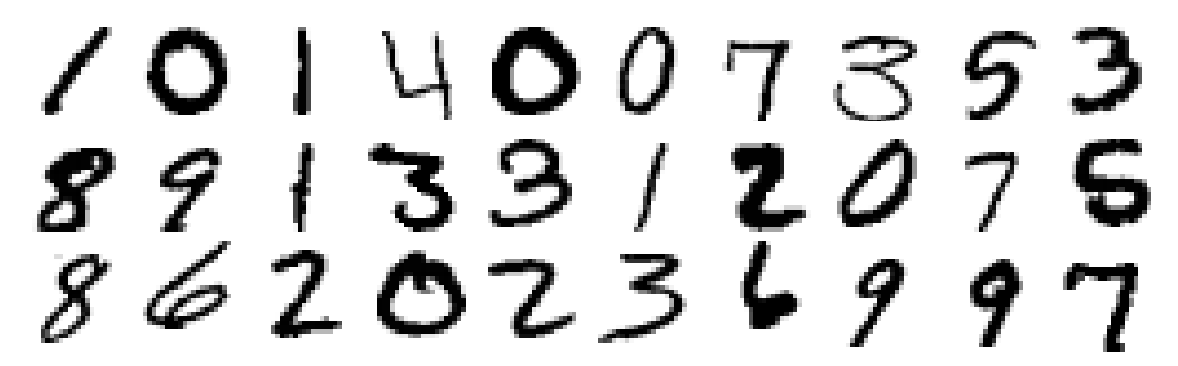

In [9]:
import matplotlib.pyplot as plt
plt.figure(figsize=(15,4.5))
for i in range(30):  
    plt.subplot(3, 10, i+1)
    plt.imshow(X_train[i].reshape((28,28)),cmap=plt.cm.binary)
    plt.axis('off')
plt.subplots_adjust(wspace=-0.1, hspace=-0.1)
plt.show()

In [10]:
datagen = ImageDataGenerator(
        rotation_range=10,  # randomly rotate images through any degree between 0 and 360
        zoom_range = 0.10,  
        width_shift_range=0.1, # a float number, that would indicate the percentage of width or height of the image to shift. 
        height_shift_range=0.1)

In [11]:
X_train.shape # (42000, 28, 28, 1)
X_train[25,].shape # (28, 28, 1)
X_train[25,].reshape((1,28,28,1)).shape # (1, 28, 28, 1)

(1, 28, 28, 1)

In [12]:
X_train[25,].shape

(28, 28, 1)

In [13]:
X_train[41999,].shape

(28, 28, 1)

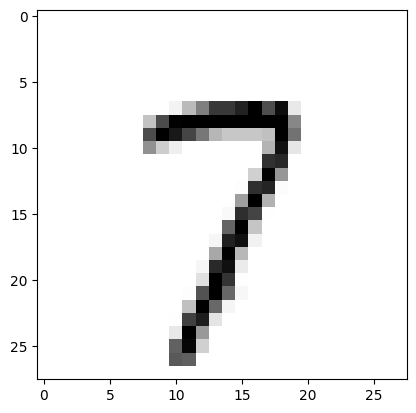

In [14]:
plt.imshow(X_train[18,].reshape((28,28)),cmap=plt.cm.binary)

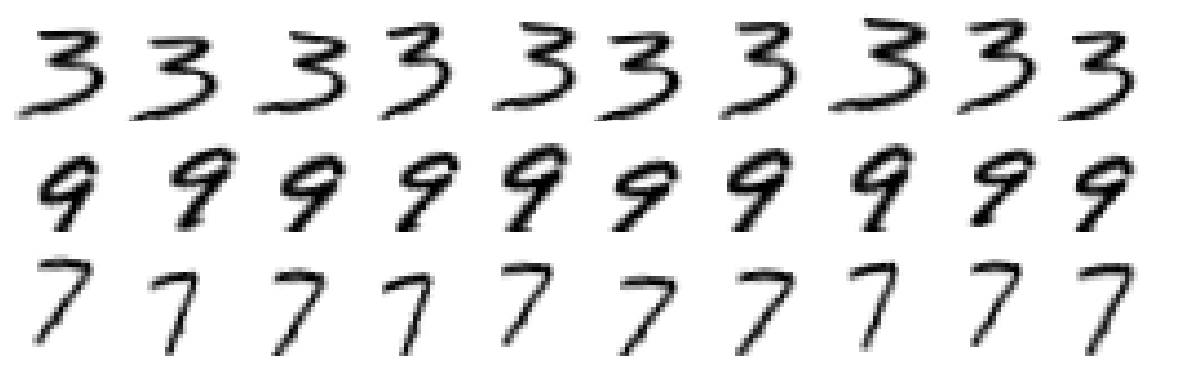

In [15]:
X_train_random = X_train[25,].reshape((1,28,28,1))
Y_train_random = Y_train[25,].reshape((1,10))

plt.figure(figsize=(15,4.5))

for i in range(30):  
    plt.subplot(3, 10, i+1)
    X_train_augmented, Y_train_augmented = datagen.flow(X_train_random,Y_train_random).next()
    plt.imshow(X_train_augmented[0].reshape((28,28)),cmap=plt.cm.binary)
    plt.axis('off')
    # Now for the second and third row take 2 different digit
    # 9 and 7 respectively
    # And because I am printing 9 columns for the same image, I have to 
    # advance the 'i' value by 10
    if i==9:
        X_train_random = X_train[11,].reshape((1,28,28,1))
    if i==19:
        X_train_random = X_train[18,].reshape((1,28,28,1))
plt.subplots_adjust(wspace=-0.1, hspace=-0.1)
plt.show()

In [16]:
def build_model(num_cnn):
    model = [0] *num_cnn
    for j in range(num_cnn):
        model[j] = Sequential()

        model[j].add(Conv2D(32, kernel_size = 3, activation='relu', input_shape = (28, 28, 1))) # Two stacked 3x3 filters instead of single 5x5 filters. 
        model[j].add(BatchNormalization()) # Batch normalization is added
        model[j].add(Conv2D(32, kernel_size = 3, activation='relu')) # and ReLU activation replaces sigmoid.
        model[j].add(BatchNormalization())
        model[j].add(Conv2D(32, kernel_size = 5, strides=2, padding='same', activation='relu')) # Stride 2 replaces pooling layers. These become learnable pooling layers.
        model[j].add(BatchNormalization())
        model[j].add(Dropout(0.4)) #  Dropout is added

        model[j].add(Conv2D(64, kernel_size = 3, activation='relu'))
        model[j].add(BatchNormalization())
        model[j].add(Conv2D(64, kernel_size = 3, activation='relu'))
        model[j].add(BatchNormalization())
        model[j].add(Conv2D(64, kernel_size = 5, strides=2, padding='same', activation='relu'))
        model[j].add(BatchNormalization())
        model[j].add(Dropout(0.4))

        model[j].add(Conv2D(128, kernel_size = 4, activation='relu'))
        model[j].add(BatchNormalization())
        model[j].add(Flatten())
        model[j].add(Dropout(0.4))
        model[j].add(Dense(10, activation='softmax'))

        model[j].compile(optimizer="adam", loss="categorical_crossentropy", metrics=["accuracy"])
    return model

In [17]:
num_cnn=10
model = build_model(num_cnn)

In [18]:
def train(num_epochs):
    # Keep reducing the Learning Rate
    lr_scheduler = LearningRateScheduler(lambda x: 1e-3 * 0.95 ** x)
    # Training starts
    history = [0] * num_cnn
    for cnn in range(num_cnn):
        X_train_split, X_val_split, Y_train_split, Y_val_split = train_test_split(
            X_train, Y_train, test_size=0.1
        )
        history[cnn] = model[cnn].fit(
            datagen.flow(X_train_split, Y_train_split, batch_size=64),
            epochs=num_epochs,
            steps_per_epoch=X_train_split.shape[0] // 64,
            validation_data=(X_val_split, Y_val_split),
            callbacks=[lr_scheduler],
            verbose=0,
        )
        print(
            "CNN {0:d}: Epochs={1:d}, Train accuracy={2:.5f}, Validation accuracy={3:.5f}".format(
                cnn + 1,
                num_epochs,
                max(history[cnn].history["accuracy"]),
                max(history[cnn].history["val_accuracy"]),
            )
        )


In [19]:
num_epochs = 45
train(num_epochs)

2023-05-20 08:53:55.945258: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential/dropout/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


CNN 1: Epochs=45, Train accuracy=0.99629, Validation accuracy=0.99595


2023-05-20 09:07:12.515509: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_1/dropout_3/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


CNN 2: Epochs=45, Train accuracy=0.99632, Validation accuracy=0.99595


2023-05-20 09:20:54.100314: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_2/dropout_6/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


...

CNN 8: Epochs=45, Train accuracy=0.99605, Validation accuracy=0.99690


2023-05-20 10:38:19.717730: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_8/dropout_24/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


CNN 9: Epochs=45, Train accuracy=0.99621, Validation accuracy=0.99643


2023-05-20 10:51:25.029135: E tensorflow/core/grappler/optimizers/meta_optimizer.cc:954] layout failed: INVALID_ARGUMENT: Size of values 0 does not match size of permutation 4 @ fanin shape insequential_9/dropout_27/dropout/SelectV2-2-TransposeNHWCToNCHW-LayoutOptimizer


CNN 10: Epochs=45, Train accuracy=0.99640, Validation accuracy=0.99690


In [20]:
X_test.shape

(28000, 28, 28, 1)

In [21]:
final_ensemble_prediction = np.zeros( (X_test.shape[0],10) )

final_ensemble_prediction.shape

(28000, 10)

In [22]:
for j in range(num_cnn):
    final_ensemble_prediction = np.zeros( (X_test.shape[0],10) )
    final_ensemble_prediction = final_ensemble_prediction + model[j].predict(X_test)

    final_ensemble_prediction = np.argmax(final_ensemble_prediction,axis = 1)
    
#     print("final_ensemble_prediction.shape ", final_ensemble_prediction.shape)

    final_ensemble_prediction = pd.Series(final_ensemble_prediction,name="Label")

    submission = pd.concat([pd.Series(range(1,28001),name = "ImageId"),final_ensemble_prediction],axis = 1)

    submission.to_csv("MNIST_ensemble_cnn.csv",index=False)
    
    print('success')

875/875 [==============================] - 2s 2ms/step
success
875/875 [==============================] - 2s 3ms/step
success
875/875 [==============================] - 2s 2ms/step
success
875/875 [==============================] - 2s 3ms/step
success
875/875 [==============================] - 2s 2ms/step
success
875/875 [==============================] - 2s 2ms/step
success
875/875 [==============================] - 2s 2ms/step
success
875/875 [==============================] - 2s 2ms/step
success
875/875 [==============================] - 2s 2ms/step
success
875/875 [==============================] - 2s 2ms/step
success
